In [9]:
import matplotlib.pyplot as plt
from electro.graphics.diagram import Spectrum

La clase Spectrum y todo diagram está pensado para realizar diagramas unicamente visuales.

El objetivo de Spectrum es dibujar el resultado del espectro a medida que se añaden señales o se aplican funciones puntuales. Esto incluye: añadir deltas, bloques, filtrar señales, mixear señales.

El bloque ejecutará en orden todas las instrucciones, actualizando internamente el valor actual del espectro.

## Añadido de bloques al espectro

In [10]:
s = Spectrum()

s.addDelta(f_center=1000, height=1.0, color="red", name="f0")
s.addBlock(500, 250)
s.addLeftTriangle(-250 + 250/2, 250, color='orange')
s.addBandStopFilter( f_low=12, f_high=15)

s

Sprectrum(componentes=4)
  Delta(
  name=		f0,
  f_center=	1000,
  width=	0,
  height=	1.0,
  color=	red,
)
  Block(
  name=		None,
  f_center=	500,
  width=	250,
  height=	1.0,
  color=	skyblue,
)
  LeftTriangle(
  name=		None,
  f_center=	-125.0,
  width=	250,
  height=	1.0,
  color=	orange,
)
  Filter bandstop(
  name=		None,
  passbands=	[(-inf, -15), (-12, 12), (15, inf)],
  passband_gain=	1.0,
  stopband_gain=	0,
)

## Ejemplo mixer

Sin mezclar: centros:

 - 1000 Hz
 - 1500 Hz
 - 500 Hz
 - -125.0 Hz
Mezclado: centros:

 - 1500 Hz
 - 500 Hz
 - 2000 Hz
 - 1000 Hz
 - 1000 Hz
 - 0 Hz
 - 375.0 Hz
 - -625.0 Hz


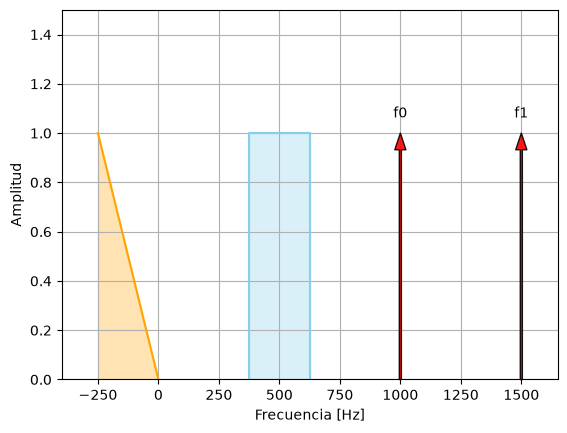

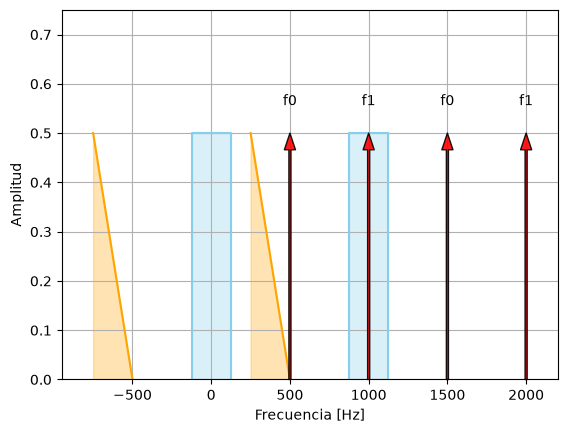

In [14]:
# Crear lista vacía de componentes
s = Spectrum()

# Agregar dos deltas
s.addDelta(f_center=1000, height=1.0, color="red", name="f0")
s.addDelta(f_center=1500, height=1.0, color="red", name="f1")
s.addBlock(500, 250)
s.addLeftTriangle(-250 + 250/2, 250, color='orange')


# Mostrar componentes originales
s.show()
print("Sin mezclar: centros:\n")
for comp in s.components:
    print(f" - {comp.f_center} Hz")

# Mezclar con portadora de 3000 Hz
s = s.mix(500)
print("Mezclado: centros:\n")
for comp in s.components:
    print(f" - {comp.f_center} Hz")
s.show();


## Ejemplo de filtrado

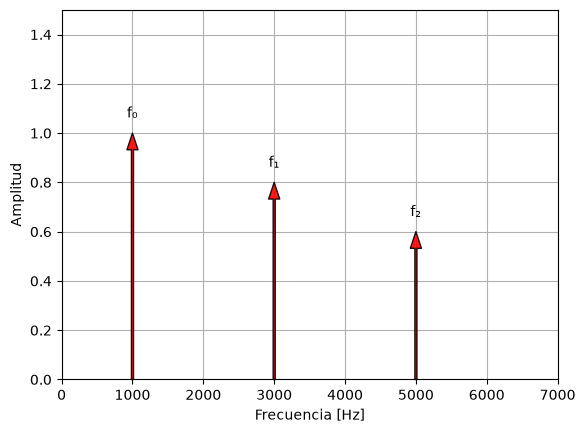

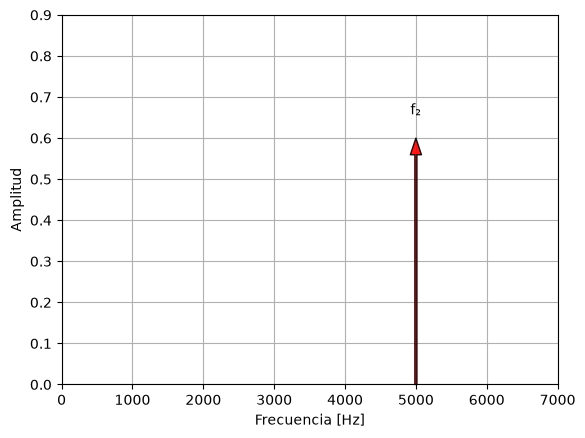

In [16]:
s = Spectrum()

# Componentes de señal
s.addDelta(1000, height=1.0, color='red', name='f₀')
s.addDelta(3000, height=0.8, color='red', name='f₁')
s.addDelta(5000, height=0.6, color='red', name='f₂')

fig, ax = s.show()
ax.set_xlim(0, 7000)
plt.show()

# Filtro elimina banda entre 2000 y 4000 Hz
s.addBandStopFilter( f_low=10, f_high=4000, color='gray', name='Filtro elimina banda')

# Mostrar
fig, ax = s.show()
ax.set_xlim(0, 7000)
plt.show()

## Ejemplo filtrado

Este ejemplo es absurdo pero cumple el propósito de llevarlo al extremo

[(-50, -40), (-20, -15), (-12, -10), (10, 12), (15, 20), (40, 50)]


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Frecuencia [Hz]', ylabel='Amplitud'>)

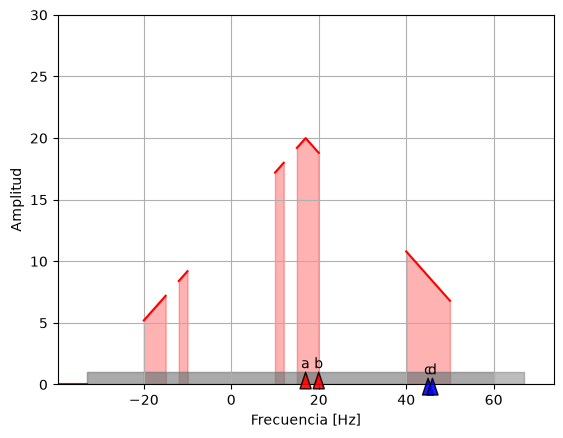

In [13]:
s = Spectrum()
s.addBandStopFilter(f_low=20, f_high=40, )
s.addBandPassFilter(f_low=10, f_high=60)
s.addLowPassFilter(f_cutoff=50)
s.addBandStopFilter(f_low=12, f_high=15)
print(s.get_passbands())

s.addDelta(17, height=1.0, color='red', name='a')
s.addDelta(20, height=1.0, color='red', name='b')
s.addDelta(45, height=0.5, color='blue', name='c')
s.addDelta(46, height=0.5, color='blue', name='d')
s.addTriangle(17,100,20,name='triangle')
s.show()